# 🧩 QR and SVD — Taking Matrices Apart

**Linear Algebra and Analytic Geometry** · TSIW, ESMAD — Polytechnic of Porto
Lesson notebook **05 of 08** · Library: [`linalg_utils`](../packages/python/src/linalg_utils)

> **Assignment alignment** — supplemental notebook (QR/SVD is not a graded assignment);
> deepens the tools used for least squares in notebook 04.

---

A factorization rewrites one complicated matrix as a product of simple, well-understood
pieces. This notebook covers the two most useful ones:

- **QR** — $A = QR$: an *orthonormal basis* $Q$ for the column space plus a *triangular*
  bookkeeping matrix $R$. Built by the **Gram–Schmidt** process — projections again!
- **SVD** — $A = U\Sigma V^{\mathsf T}$: *every* matrix is a rotation, then an axis-aligned
  stretch, then another rotation. The stretch factors (singular values) rank the directions
  that matter, enabling **low-rank compression**.

## Table of contents

1. [Setup](#setup)
2. [Gram–Schmidt: orthonormalizing step by step](#gs)
3. [QR with the course library](#qr)
4. [SVD: rotate · stretch · rotate](#svd)
5. [Reconstruction and the rank-1 view](#reconstruction)
6. [Low-rank approximation: image compression](#lowrank)
7. [Key takeaways](#takeaways)

<a id="setup"></a>
## 1 · Setup

In [1]:
# ── Setup: imports, course library, and a consistent figure style ──────────
import sys
from pathlib import Path

# Make the course library importable straight from a repo clone
# (equivalent to `poetry install` inside packages/python).
_SRC = (Path.cwd().parent / "packages" / "python" / "src").resolve()
if _SRC.exists() and str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))

import numpy as np
import matplotlib.pyplot as plt

# Colorblind-safe categorical palette, used in fixed order across the series.
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
           "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK, MUTED, GRID, BASE = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor":   "#fcfcfb",
    "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor":   BASE,
    "axes.labelcolor":  INK,
    "axes.titlecolor":  INK,
    "axes.titleweight": "bold",
    "axes.grid":        True,
    "grid.color":       GRID,
    "grid.linewidth":   0.8,
    "xtick.color":      MUTED,
    "ytick.color":      MUTED,
    "axes.prop_cycle":  plt.cycler(color=PALETTE),
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "legend.frameon":   False,
    "figure.dpi":       110,
})
np.set_printoptions(precision=4, suppress=True)

import linalg_utils
print("NumPy", np.__version__, "| linalg_utils loaded from", Path(linalg_utils.__file__).parent)

NumPy 2.3.5 | linalg_utils loaded from C:\Users\diogo\work_code\linear-algebra-with-python\packages\python\src\linalg_utils


<a id="gs"></a>
## 2 · Gram–Schmidt: orthonormalizing step by step

Given independent vectors $\mathbf{a}_1, \mathbf{a}_2, \dots$, Gram–Schmidt manufactures an
**orthonormal** set spanning the same space, one vector at a time:

$$\mathbf{q}_1 = \frac{\mathbf{a}_1}{\lVert\mathbf{a}_1\rVert}, \qquad
\mathbf{q}_2 = \frac{\mathbf{a}_2 - \underbrace{(\mathbf{q}_1^{\mathsf T}\mathbf{a}_2)\,\mathbf{q}_1}_{\text{projection onto } \mathbf{q}_1}}
{\lVert \cdots \rVert}, \qquad \dots$$

Each new vector has its shadows along the previous $\mathbf{q}$'s **subtracted** — only the
genuinely new direction survives. We trace the 2-D case visually.

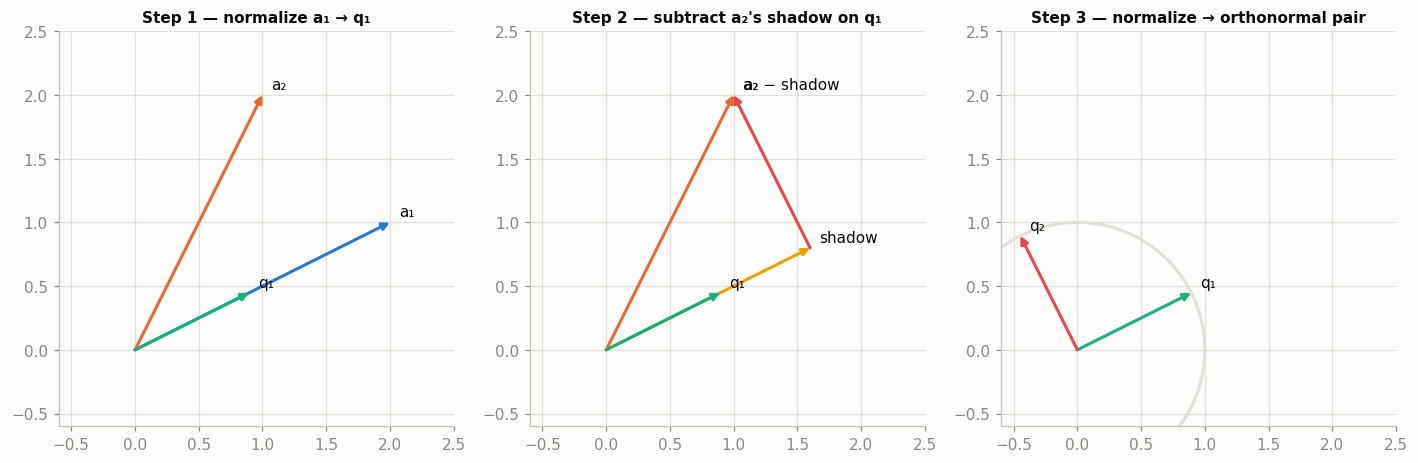

q₁ · q₂ = +1.67e-16   (orthogonal ✔)
‖q₁‖ = 1.000000, ‖q₂‖ = 1.000000   (unit length ✔)


In [2]:
a1 = np.array([2.0, 1.0])
a2 = np.array([1.0, 2.0])

q1 = a1 / np.linalg.norm(a1)
shadow = (q1 @ a2) * q1          # projection of a2 on q1
w = a2 - shadow                  # what's left: orthogonal to q1
q2 = w / np.linalg.norm(w)


def draw_vector(ax, vec, *, color, label, origin=(0.0, 0.0), ls="-"):
    ax.annotate("", xy=(origin[0] + vec[0], origin[1] + vec[1]), xytext=origin,
                arrowprops=dict(arrowstyle="-|>", color=color, lw=2,
                                linestyle=ls, shrinkA=0, shrinkB=0))
    ax.annotate(label, xy=(origin[0] + vec[0], origin[1] + vec[1]), xytext=(6, 4),
                textcoords="offset points", color=INK, fontsize=10)


fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
titles = ["Step 1 — normalize a₁ → q₁",
          "Step 2 — subtract a₂'s shadow on q₁",
          "Step 3 — normalize → orthonormal pair"]
for ax, t in zip(axes, titles):
    ax.set_xlim(-0.6, 2.5)
    ax.set_ylim(-0.6, 2.5)
    ax.set_aspect("equal")
    ax.set_title(t, fontsize=10)

draw_vector(axes[0], a1, color=PALETTE[0], label="a₁")
draw_vector(axes[0], a2, color=PALETTE[1], label="a₂")
draw_vector(axes[0], q1, color=PALETTE[2], label="q₁")

draw_vector(axes[1], a2, color=PALETTE[1], label="a₂")
draw_vector(axes[1], shadow, color=PALETTE[3], label="shadow")
draw_vector(axes[1], w, origin=tuple(shadow), color=PALETTE[7], label="a₂ − shadow")
draw_vector(axes[1], q1, color=PALETTE[2], label="q₁")

draw_vector(axes[2], q1, color=PALETTE[2], label="q₁")
draw_vector(axes[2], q2, color=PALETTE[7], label="q₂")
th = np.linspace(0, 2 * np.pi, 100)
axes[2].plot(np.cos(th), np.sin(th), color=GRID, lw=2, zorder=0)
plt.tight_layout()
plt.show()

print(f"q₁ · q₂ = {q1 @ q2:+.2e}   (orthogonal ✔)")
print(f"‖q₁‖ = {np.linalg.norm(q1):.6f}, ‖q₂‖ = {np.linalg.norm(q2):.6f}   (unit length ✔)")

<a id="qr"></a>
## 3 · QR with the course library

Running Gram–Schmidt on all columns of $A$ *and writing down the shadows we subtract* yields
the factorization $A = QR$:

- $Q$ — the orthonormal vectors, as columns ($Q^{\mathsf T}Q = I$);
- $R$ — upper triangular, holding the projection coefficients and norms. Triangular, because
  column $j$ of $A$ only ever involves $\mathbf{q}_1,\dots,\mathbf{q}_j$.

`linalg_utils.decompositions.qr_gram_schmidt` implements the classical process and the
`checks` module certifies the two structural properties.

Q =
 [[ 0.8944 -0.3586]
 [ 0.4472  0.7171]
 [ 0.      0.5976]]
R =
 [[1.118  1.7889]
 [0.     1.6733]] 

QᵀQ = I?           True
R upper-triangular? True
Q @ R == A to 1e-12 ✔


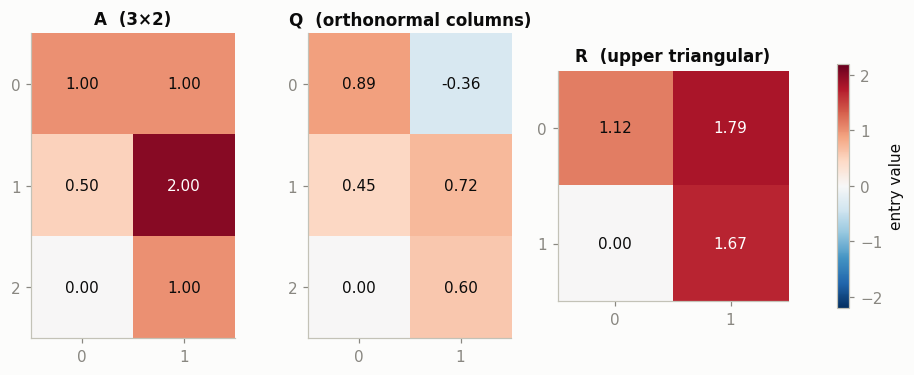

In [3]:
from linalg_utils.decompositions import qr_gram_schmidt
from linalg_utils.checks import is_orthonormal, is_upper_triangular, assert_close

A = np.array([[1.0, 1.0],
              [0.5, 2.0],
              [0.0, 1.0]])

Q, R = qr_gram_schmidt(A)
print("Q =\n", Q)
print("R =\n", R, "\n")

print("QᵀQ = I?          ", is_orthonormal(Q))
print("R upper-triangular?", is_upper_triangular(R))
assert_close("QR reconstructs A", Q @ R, A, tol=1e-12)
print("Q @ R == A to 1e-12 ✔")

# Structure at a glance: Q's columns are unit & orthogonal, R stores the recipe.
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.6))
for ax, (M, title) in zip(axes, [(A, "A  (3×2)"), (Q, "Q  (orthonormal columns)"),
                                 (R, "R  (upper triangular)")]):
    im = ax.imshow(M, cmap="RdBu_r", vmin=-2.2, vmax=2.2)
    ax.set_title(title, fontsize=11)
    ax.grid(False)
    for (i, j), val in np.ndenumerate(M):
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=10,
                color=INK if abs(val) < 1.4 else "white")
    ax.set_xticks(range(M.shape[1]))
    ax.set_yticks(range(M.shape[0]))
fig.colorbar(im, ax=axes, shrink=0.8, label="entry value")
plt.show()

<a id="svd"></a>
## 4 · SVD: rotate · stretch · rotate

The **singular value decomposition** factors *any* matrix — square or not, invertible or
not — as

$$A = U\,\Sigma\,V^{\mathsf T}, \qquad
U, V \text{ orthogonal}, \quad \Sigma = \operatorname{diag}(\sigma_1 \ge \sigma_2 \ge \dots \ge 0).$$

Read right-to-left, $A\mathbf{x} = U(\Sigma(V^{\mathsf T}\mathbf{x}))$ says every linear map
is: **rotate** (by $V^{\mathsf T}$) → **stretch along the axes** (by $\Sigma$) → **rotate**
(by $U$). We watch each stage act on the unit circle: the singular values $\sigma_1, \sigma_2$
are precisely the semi-axes of the final ellipse — the "most/least stretched" directions
spotted back in notebook 02.

singular values: [3.618 1.382]


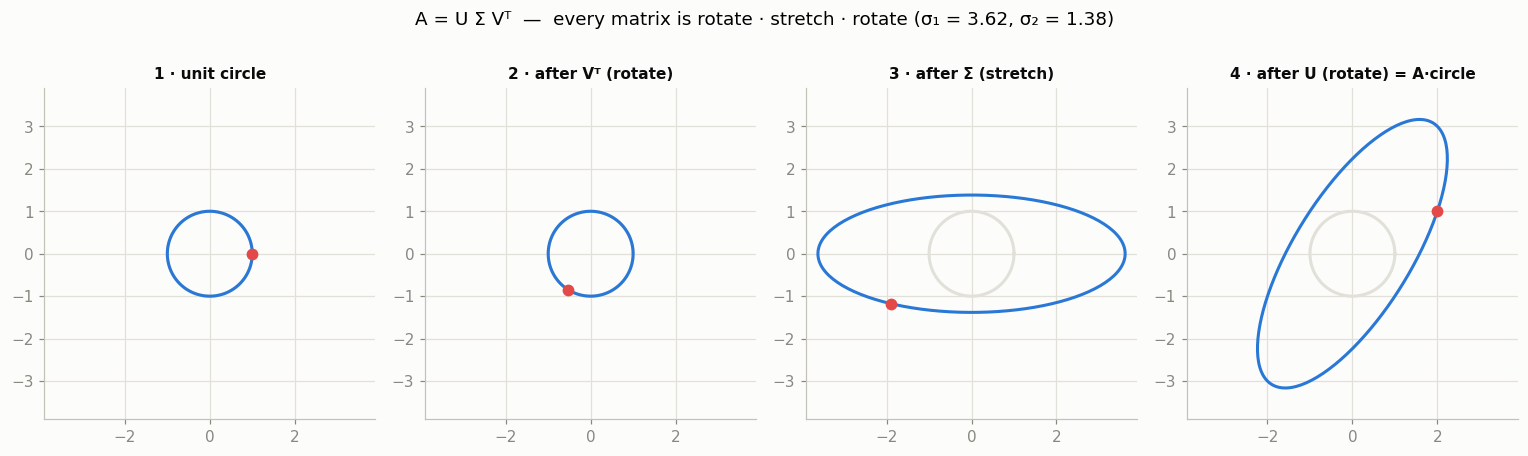

In [4]:
from linalg_utils.geometry2d import unit_circle, apply_linear_map

M = np.array([[2.0, 1.0],
              [1.0, 3.0]])
U_svd, sigma, VT = np.linalg.svd(M)
print("singular values:", sigma)

circle = unit_circle()
stages = [
    ("1 · unit circle", circle),
    ("2 · after Vᵀ (rotate)", apply_linear_map(VT, circle)),
    ("3 · after Σ (stretch)", apply_linear_map(np.diag(sigma) @ VT, circle)),
    ("4 · after U (rotate) = A·circle", apply_linear_map(M, circle)),
]

fig, axes = plt.subplots(1, 4, figsize=(14, 3.8))
for ax, (title, pts) in zip(axes, stages):
    ax.plot(circle[:, 0], circle[:, 1], color=GRID, lw=2, zorder=0)
    ax.plot(pts[:, 0], pts[:, 1], color=PALETTE[0], lw=2)
    # track one marked point through the stages to make the motion visible
    ax.scatter(*pts[0], s=45, color=PALETTE[7], zorder=3)
    ax.set_xlim(-3.9, 3.9)
    ax.set_ylim(-3.9, 3.9)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=10)
fig.suptitle("A = U Σ Vᵀ  —  every matrix is rotate · stretch · rotate "
             f"(σ₁ = {sigma[0]:.2f}, σ₂ = {sigma[1]:.2f})", y=1.04)
plt.tight_layout()
plt.show()

<a id="reconstruction"></a>
## 5 · Reconstruction and the rank-1 view

Multiplying the factors back must reproduce $A$ exactly. More interestingly, the SVD is a
**sum of rank-1 layers**, one per singular value:

$$A \;=\; \sum_{k} \sigma_k \, \mathbf{u}_k \mathbf{v}_k^{\mathsf T}
\qquad\text{(largest } \sigma \text{ first — most important layer first).}$$

Truncating the sum after $r$ terms gives the **best rank-$r$ approximation** of $A$
(Eckart–Young theorem) — the theoretical engine behind compression and PCA.

In [5]:
S = np.diag(sigma)
reconstruction = U_svd @ S @ VT
print("‖A − UΣVᵀ‖ =", np.linalg.norm(M - reconstruction), " (machine precision ✔)\n")

layer1 = sigma[0] * np.outer(U_svd[:, 0], VT[0])
layer2 = sigma[1] * np.outer(U_svd[:, 1], VT[1])
print("σ₁·u₁v₁ᵀ =\n", layer1)
print("σ₂·u₂v₂ᵀ =\n", layer2)
print("sum =\n", layer1 + layer2, "\n= A ✔")

‖A − UΣVᵀ‖ = 8.308148362110449e-16  (machine precision ✔)

σ₁·u₁v₁ᵀ =
 [[1.    1.618]
 [1.618 2.618]]
σ₂·u₂v₂ᵀ =
 [[ 1.    -0.618]
 [-0.618  0.382]]
sum =
 [[2. 1.]
 [1. 3.]] 
= A ✔


<a id="lowrank"></a>
## 6 · Low-rank approximation: image compression

The rank-1 layers become spectacular on a bigger matrix. We build a 64×64 grayscale test
image, treat it as a matrix, and keep only the top-$r$ singular layers. A handful of layers
out of 64 already captures the structure — the singular values decay fast, and the storage
cost drops from $64^2$ numbers to $r(2\cdot 64 + 1)$.

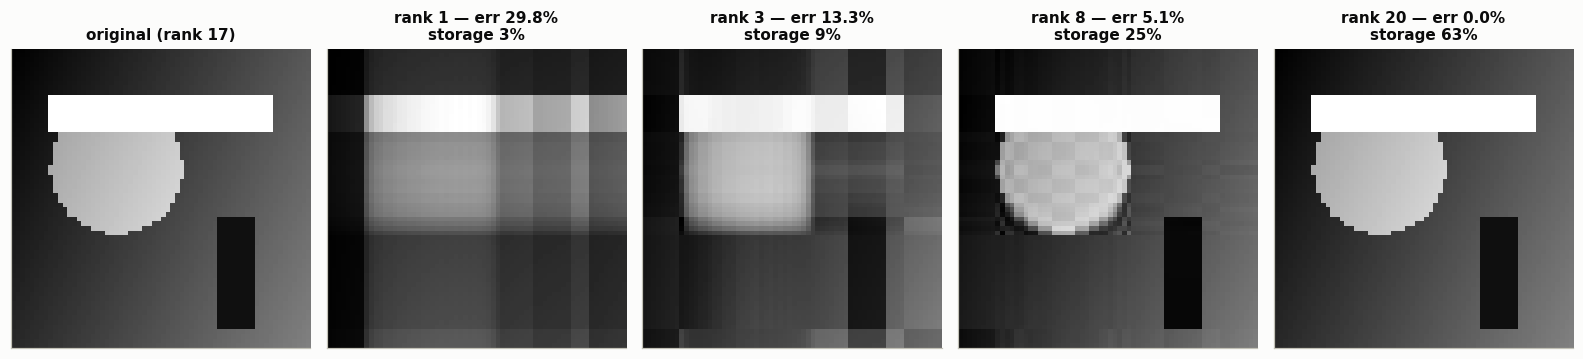

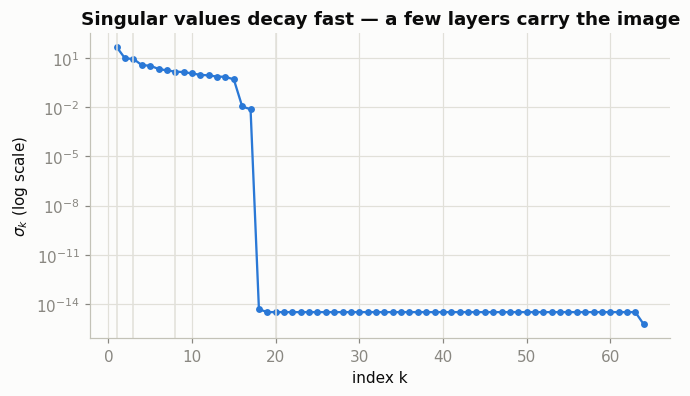

In [6]:
# A synthetic 64×64 image: smooth gradient + circle + bars (structure at several scales).
n = 64
yy, xx = np.mgrid[0:n, 0:n] / (n - 1)
img = 0.55 * xx + 0.25 * yy                                  # gradient background
img += 0.9 * ((xx - 0.35) ** 2 + (yy - 0.4) ** 2 < 0.05)     # disc
img[10:18, 8:56] = 1.6                                       # horizontal bar
img[36:60, 44:52] = 0.1                                      # vertical bar

Ui, si, Vti = np.linalg.svd(img)
ranks = [1, 3, 8, 20]

fig, axes = plt.subplots(1, len(ranks) + 1, figsize=(14.5, 3.4))
axes[0].imshow(img, cmap="gray")
axes[0].set_title(f"original (rank {np.linalg.matrix_rank(img)})", fontsize=10)
for ax, r in zip(axes[1:], ranks):
    approx = Ui[:, :r] @ np.diag(si[:r]) @ Vti[:r]
    rel_err = np.linalg.norm(img - approx) / np.linalg.norm(img)
    ax.imshow(approx, cmap="gray")
    ax.set_title(f"rank {r} — err {rel_err:.1%}\nstorage {r * (2 * n + 1) / n**2:.0%}",
                 fontsize=10)
for ax in axes:
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6.8, 3.6))
ax.semilogy(np.arange(1, n + 1), si, marker="o", ms=3.5, lw=1.5, color=PALETTE[0])
for r in ranks:
    ax.axvline(r, color=GRID, lw=1)
ax.set_xlabel("index k")
ax.set_ylabel(r"$\sigma_k$ (log scale)")
ax.set_title("Singular values decay fast — a few layers carry the image")
plt.show()

<a id="takeaways"></a>
## 7 · Key takeaways

- **QR** packages Gram–Schmidt: $Q$ holds an orthonormal basis of the column space, the
  triangular $R$ remembers the projection coefficients — and it is the stable route to least
  squares (notebook 04).
- **SVD** works for *every* matrix: rotate · stretch · rotate, with the singular values as
  the stretch factors / semi-axes of the image ellipse.
- $A = \sum_k \sigma_k \mathbf{u}_k\mathbf{v}_k^{\mathsf T}$ orders information by
  importance; truncating gives the **best** low-rank approximation (Eckart–Young).
- Fast-decaying singular values = compressible structure — the principle behind image
  compression here and PCA in notebook 07.

**Next:** [06 — Eigenvalues and diagonalization](06_eigenvalues_and_diagonalization.ipynb):
the directions a matrix maps onto themselves.